Study Hour   Mark   Weight
---------------------------
   1.0       35   0.000
   2.0       45   0.002
   3.0       52   0.044
   4.0       60   0.325
   5.0       68   0.882
   6.0       75   0.882
   7.0       82   0.325
   8.0       88   0.044
   9.0       93   0.002

New student studies: 5.5 hours
Predicted Mark: 71.31


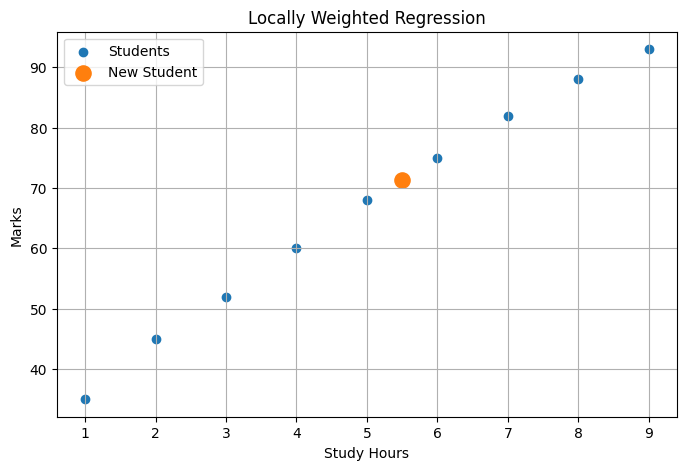

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=float)
y = np.array([35, 45, 52, 60, 68, 75, 82, 88, 93], dtype=float)

# New student
query = 5.5

# Bandwidth parameter
tau = 1.0

# Calculate Gaussian weights
weights = np.exp(-((X - query) ** 2) / (2 * tau ** 2))

# Display weights
print("Study Hour   Mark   Weight")
print("---------------------------")

for hour, mark, weight in zip(X, y, weights):
    print(f"{hour:^10.1f} {mark:^6.0f} {weight:.3f}")

# Add column of 1s for intercept
X_design = np.column_stack((np.ones(len(X)), X))

# Create weight matrix
W = np.diag(weights)

# Weighted Linear Regression
theta = np.linalg.pinv(
    X_design.T @ W @ X_design
) @ X_design.T @ W @ y

# Prediction for new student
prediction = np.array([1, query]) @ theta

# Display prediction
print("\nNew student studies:", query, "hours")
print("Predicted Mark:", round(prediction, 2))

# Plot original data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Students")

# Plot predicted student
plt.scatter(query, prediction, s=120, label="New Student")

# Labels and title
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Locally Weighted Regression")
plt.legend()
plt.grid(True)

# Show plot
plt.show()